# Bootstrapping Zero Prices With FEDInvest Data

<div style="display: flex; flex-wrap: wrap; align-items: center; gap: 15px; margin-bottom: 25px; padding-bottom: 15px; border-bottom: 1px solid #eaeaea;">
  
  <a href="https://colab.research.google.com/github/PatrickJHess/Volume-Three-Chapter-Three/blob/master/colab/Colab_Bootstrappinmg_Zero_Prices.ipynb" target="_blank" style="display: flex; align-items: center;">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="height: 28px; margin: 0;">
  </a>

  <a href="https://mybinder.org/v2/gh/PatrickJHess/Volume-Three-Chapter-Three/master?urlpath=lab/tree/notebooks/Bootstrappinmg Zero Prices.ipynb" target="_blank" style="background-color: #f5a252; color: white; padding: 0 12px; text-decoration: none; font-weight: bold; border-radius: 4px; font-family: sans-serif; display: flex; align-items: center; font-size: 0.9em; height: 28px; box-sizing: border-box;">
    <span style="margin-right: 6px; font-size: 1.1em;">🚀</span> Launch Live in Binder
  </a>

  <a href="https://patrickjhess.github.io/Volume-Three-Chapter-Three/" style="background-color: #f1f3f4; color: #3c4043; border: 1px solid #dadce0; padding: 0 12px; text-decoration: none; font-weight: bold; border-radius: 4px; font-family: sans-serif; display: flex; align-items: center; font-size: 0.9em; height: 28px; box-sizing: border-box;">
    <span style="margin-right: 6px; font-size: 1.1em;">⬅️</span> Return to Main Book
  </a>
</div>

An important step  in constructing the term structure utilizes coupon bonds to estimate zero prices, a process commonly known as bootstrapping zero prices or present-value factors. When done with ordinary least squares (OLS),the result is a collection of discrete zero prices: a basis for calculating spot and forward rates for specific dates. In this notebook, FEDInvest data is used to bootstrapp zero prices with OLS.

As we proceed, two critical considerations should be noted:

1. Bootstrapping wih OLS is a first approximaton of term structure estimation. Because the term structure is essential for pricing various financial instruments, discrete estimates alone are inadequate; the gaps between these points must be addressed, the focus of the following chapter.  
2. The reliability of any estimate is fundamentally tied to the quality of the underlying data. While the FEDInvest data may not represent the current state of the art, it remains highly effective for demonstrating core concepts that are applicable throughout a professional career.

:::{important} [ ▼ ] How to use this page: Run, Copy, & Download
:class: dropdown

<ul>
  <li><b>⏻ Run code right here:</b> Click the <b>Power Button</b> icon at the top of the screen to activate <b>Live Code</b>.</li>
  <li><b>📋 Copy code:</b> Hover over any code block and click the <b>Clipboard icon</b> in the top-right corner.</li>
  <li><b>📥 Download this file:</b> Click the <b>Download icon</b> (downward arrow) at the top right of the screen to save this exact notebook to your computer.</li>
</ul>
:::

:::{important} 🛠️ Notebook Setup: Why the "Try/Except" Imports?
:class: dropdown

**The Goal:**
To ensure this notebook runs perfectly whether you are using **Google Colab**, a local **Jupyter instance**, or a remote server without you having to manually install software.

* **External Libraries:** NumPy and Pandas are the "heavy hitters" for data. They aren't always installed by default.
* **The `try/except` Logic:** This is a safety net.
    1. We **try** to import the library.
    2. If it fails (because it's not installed), the **except** block triggers a `!pip install` to download it automatically.
* **Aliasing (`as np`):** We rename `numpy` to `np` to save keystrokes. In professional finance code, `np` and `pd` are the universal shorthand.
  
:::

## Preparing the notebook

### Importing libraries, modules, And functions

Modules that are included in the standard Python library are imported. When necessary, other modules or libraries are installed before they are imported.  (see [Control Statements](https://patrickjhess.github.io/Introduction-To-Python-For-Financial-Python/Control_Statements.html#the-try-and-except)).

```
import os
import sys
import requests
from datetime import datetime
from types import ModuleType


try:
    import numpy as np
except:
    !pip -q install numpy
    import numpy as np

try:
    import pandas as pd
except:
    !pip -q install pandas
    import pandas as pd
```

In [1]:
import os
import sys
import requests
from datetime import datetime, date
from types import ModuleType
import calendar

try:
    import numpy as np
except:
    !pip -q install numpy
    import numpy as np

try:
    import pandas as pd
except:
    !pip -q install pandas
    import pandas as pd

:::{important} ☁️ Cloud-Loading: How In-Memory Modules Work
:class: dropdown

**The Logic:**
Usually, Python looks for modules as `.py` files on your hard drive. Here, we are "tricking" Python into treating a string of text from a URL as a live library.

**The Workflow:**
1. **Fetch:** `requests.get(url)` grabs the raw text of your Python script from Dropbox.
2. **Instantiate:** `ModuleType(module_name)` creates an empty "container" in your computer's RAM.
3. **Execute:** `exec(code, module.__dict__)` runs that text inside the container, turning text into live functions.
4. **Register:** By adding it to `sys.modules`, we tell Python: *"If I try to import this later, don't look on the disk—look right here in the memory."*

**Why do this?**
It makes your notebooks **100% portable**. A user can open this in a brand-new environment, and as long as they have an internet connection, all your custom financial functions will "just work."
:::

### Adding a custom module and importing functions


Similar to Chapter One, this notebook utilizes the custom module, **module_basic_concepts_fixed_income**, sourced from Dropbox and named `basic_concepts_fixed_income`. As a reminder, the module is accessible in the notebook's memory, but is not added to a drive.  

The functions `FEDInvest` and `clean_FEDInvest` of the notebook *Treasury Direct Data* are imported. In addition two new functions (`scheduled_bond_payments` and `accrued_interest`) are imported.


```
try:
    response = requests.get(url)
    module = ModuleType(module_name)
    exec(response.text, module.__dict__)
    sys.modules[module_name] = module
    # Now we can import from our in-memory module
    from module_basic_concepts_fixed_income import (FEDInvest,
                                                   clean_FEDInvest,
                                                   accrued_interest,
                                                   create_payoff_df,
                                                   one_y_axis)
                                                   
except requests.exceptions.RequestException as e:
    print(f"❌ Error: Could not fetch module from URL. {e}")
except Exception as e:
    print(f"❌ Error: Failed to execute or import the module. {e}")
    # Now we can import from our in-memory module
```



In [2]:
# Define the URL of the Python module to be downloaded from Dropbox.
# The 'dl=1' parameter in the URL forces a direct download of the file content.
url= 'https://www.dropbox.com/scl/fi/4y5hjxlfphh1ngvbgo77q/\
module_-basic_concepts_fixed_income.py?rlkey=6oxi7mgka42veaat79hcv8boz&st=87sztshr&dl=1'
module_name='basic_concepts_fixed_income'
# Send an HTTP GET request to the URL and store the server's response.
try:
    response = requests.get(url)
    module = ModuleType(module_name)
    exec(response.text, module.__dict__)
    sys.modules[module_name] = module
    # Now we can import from our in-memory module
    from basic_concepts_fixed_income import (FEDInvest,
                                             clean_FEDInvest,
                                             accrued_interest,
                                             create_payoff_df,
                                              one_y_axis)
except requests.exceptions.RequestException as e:
    print(f"❌ Error: Could not fetch module from URL. {e}")
except Exception as e:
    print(f"❌ Error: Failed to execute or import the module. {e}")
    # Now we can import from our in-memory module

In [45]:
my_date=datetime(2026, 4,27)
# Fetch Treasury data for a specific date
df, stamp,settlement = FEDInvest(my_date)

#Display price and date and settlement
display(f'Date of prices {stamp}  Settlement date  {settlement}')

# Display the first few rows
df.head()

'Date of prices 2026-04-27  Settlement date  2026-04-28'

,CUSIP,SECURITY TYPE,RATE,MATURITY DATE,CALL DATE,BUY,SELL,END OF DAY
1,912797SN8,MARKET BASED BILL,0.000%,2026-04-30,NaN,0.000000,99.970000,99.980111
2,912797TL1,MARKET BASED BILL,0.000%,2026-05-05,NaN,99.920333,99.920000,99.930389
3,912797SP3,MARKET BASED BILL,0.000%,2026-05-07,NaN,99.900556,99.900278,99.910000
4,912797TR8,MARKET BASED BILL,0.000%,2026-05-12,NaN,99.850417,99.850000,99.860000
5,912797QN0,MARKET BASED BILL,0.000%,2026-05-14,NaN,99.830708,99.830472,99.840444


In [4]:
clean_df=clean_FEDInvest(df)
demo_df=clean_df.head()
display(demo_df)

,SECURITY TYPE,Coupon,Price Ask,Price Bid,END OF DAY
MATURITY DATE,,,,,
2026-04-30,MARKET BASED BILL,0.000,0.000000,99.97000,99.980111
2026-04-30,MARKET BASED NOTE,4.875,0.000000,100.00000,100.000000
2026-04-30,MARKET BASED NOTE,0.750,0.000000,99.96875,99.968750
2026-04-30,MARKET BASED NOTE,2.375,0.000000,99.96875,100.000000
2026-05-05,MARKET BASED BILL,0.000,99.920333,99.92000,99.930389


## Creating the payoff matrix
Our primary goal is to construct a DataFrame to organize payment information following the collection of bond price data for 399 securities on Apr 27, 2026. This matrix is initially populated with zeros, using rows for each of the 399 securities and columns for payment dates derived from unique maturity dates adjusted for settlement.

To maintain full column rank within the payoff matrix when zero prices are estimated with ordnary least squres (OLS), bond inclusion is restricted to those whose payment dates that match zero prices at unique maturity dates. Given that the entire FEDInvest security set is unlikely to satisfy these conditions, we rigorously verify each bond's payoff dates against the 268 unique maturity dates of the 399 bonds. `OLS` defaults to False, but if assigned True, the payoff matrix concludes with the addition of the previous bond.

Once all eligible bonds are processed, the DataFrame is refined to include only those rows and columns containing non-zero values.

The `create_payoff_df` function generates this payoff DataFrame by accepting an argument such as `clean_df`. During processing, the function evaluates bond payment dates against the `all_maturities` set. A completion indicator is included to manage the time-intensive nature of processing hundreds of bonds, reaching 100% only after all eligible securities are added.

````{dropdown} 🔍 Click to see <code>create_payoff_df</code> 

```python
def create_payoff_df(df, settlement,OLS=False):
    adjusted_maturities = adjust_bond_pay_dates(list(df.index))
    all_maturities = set(adjusted_maturities)

    df_payoff_columns = sorted(all_maturities)
    df_payoff_index=[i for i in range(len(df.index))]

    df_payoff = pd.DataFrame(
        np.zeros((len(df), len(df_payoff_columns))),
        columns=df_payoff_columns,
        index=df_payoff_index
    )
    total_rows = len(df)
    # Define a clean, pleasing HTML template for our status box
    def status_box(current, total):
        return f"""
        <div style="font-family: Arial, sans-serif; padding: 10px 15px; background-color: #f8f9fa; 
                    border-left: 4px solid #007bff; border-radius: 4px; width: fit-content; color: #333;">
            <b style="color: #007bff;">⚙️ Processing Bonds:</b> {current} of {total} added to DataFrame
        </div>
        """
    
    # initial display showing 0 bonds added
    progress_ui = display(HTML(status_box(0, total_rows)), display_id=True)

    for index,(maturity, coupon) in enumerate(zip(df.index, df['Coupon'])):

        # bond_pay_data returns payment dates and amounts
        row_pay_data = bond_pay_data(maturity, coupon, settlement=settlement)

        # Find any dates that aren't already columns
        new_dates = set(row_pay_data[0].flatten()) - all_maturities

        if new_dates:
          if OLS:
            df_clean = df_payoff.loc[(df_payoff != 0).any(axis=1),
                                         (df_payoff != 0).any(axis=0)]
            print("✅ DataFrame Complete (Exited Early)!")
            return df_clean
          else:
            # ✅ FIX: Add new dates to our master set and reindex
            all_maturities.update(new_dates)
            df_payoff = df_payoff.reindex(columns=sorted(all_maturities), fill_value=0.0)
 
        #    fill up the columns
        df_payoff.loc[index, row_pay_data[0]] = row_pay_data[1]
         # update the progress bar
        progress_ui.update(HTML(status_box(index + 1, total_rows)))
    # re-sort the columns so dates are chronological
    df_payoff = df_payoff.reindex(sorted(df_payoff.columns), axis=1)
    progress_ui.update(HTML("""
        <div style="font-family: Arial, sans-serif; padding: 10px 15px; background-color: #e6f4ea; 
                    border-left: 4px solid #34a853; border-radius: 4px; width: fit-content; color: #137333;">
            <b>✅ DataFrame Complete!</b> All bonds added successfully.
            </div>
            """))
    return df_payoff
```
````
````{dropdown} ✂️ Code snippet to see an example of the function.

```python
# assumes that create_payoff_df has been imported
# and that clean_df has been created
from IPython.display import display, HTML
import pandas as pd
# set OLS to True for ordinatry least squares
df_payoff_matrix=create_payoff_df(clean_df[:10],settlement,OLS=True)
display(df_payoff_matrix)
```
````


## Creating a DataFrame for OLS from the FEDInvest April 27<sup>th</sup> 2026.

By constructing the df_payoff_matrix should yield a full-rank matrix. We can confirm this using NumPy.`linalg.matrix_rank`. The module accepts DataFrames directly so there is need to convert the DataFrame to a NumPy array.


In [49]:
# the completon index assumes all the bonds are processed
df_payoff_matrix=create_payoff_df(clean_df,settlement,OLS=True)

# full rank rquired to infer zero prices
# linalg module to confirm full rank
rank=np.linalg.matrix_rank(df_payoff_matrix)
num_columns=df_payoff_matrix.shape[1]

# show rank and shape of DataFrame
if rank<num_columns:
 text='Payoff matrix is not full rank'
else:
 text='Payoff matrix is full rank'
display(f'{text}, Ranks is {rank}, Shape is {df_payoff_matrix.shape} ')

✅ DataFrame Complete (Exited Early)!


'Payoff matrix is full rank, Ranks is 193, Shape is (302, 193) '

### A few observations about the results
For approximately 75% of the bonds (302 out of 399), all payment dates successfully mapped to a maturity date, resulting in 193 unique payment dates (the columns of our DataFrame). We will utilize this cash flow matrix, combined with the bonds' transaction (dirty) prices, to determine the least-squares zero prices. Before estimating these zero prices, we must first calculate the dirty prices by adding the accrued interest to the quoted (clean) prices.



:::::{admonition} ✍️ Application: Create a DataFrame of payoff data OLS with June 1<sup>st</sup> 2023 data from FEDInvest site and calculate the rank. 


**The Challenge**:Using the functions `FEDInvest`, `Clean_FEDInvest`, and `create_payoff_df`


*Recall:* 
1. The pricing date (sole argument of FEDInvest) must be datetime object (either `'date` or `datetime`.
2. FEDInvest returns a DataFrame, the pricing and settlement dates.
3. The lialg module of NumPy has a function `rank`

**Goal**: Test your ability to use the functions and determine the rank of the payoff matrix 

---
    
::::{dropdown} 🛟 Need hints or a solution?

:::{dropdown} 💡 Hints

* **Imports:** If you are using a different notebook, import libraries and modules and `FEDInvest`. `Clean_FEDInvest` for the custom module. Refer to Preparing Notebook section.
* **Create the pricing date:** 'date(year,month,day)`
* **Use functions:** `FEDInvest`, `Clean_FEDInvest`, `create_payoff_df`, NumPy `rank`
  


:::

:::{dropdown} ✅ Example Of Solution
## Example of Code


```py
# price datetime
from datetime import datetime
import numpy as np
price_date=date(2023,6,1)
 
# get the data with FEDInvest (returns pricing and settlement as well DataFrame)
df_app,pricing_date,settlement=FEDInvest(price_date)

# standardize the DataFrame
clean_df_app=clean_FEDInvest(df_app)

# calculate the payoff matrix DataFrame
df_payoff_matrix_app=create_payoff_df(clean_df_app,settlment,OLS=True)

# calculate and number of columns of DataFrame
rank=np.linalg.matrix_rank(df_payoff_matrix_app)
num_columns=df_payoff_matrix_app.shape[1]

# show rank and shape of DataFrame
if rank<num_columns:
 text='Payoff matrix is not full rank'
else:
 text='Payoff matrix is full rank'
display(f'{text}, Ranks is {rank}, Shape is {df_payoff_matrix_app.shape} ')

```
:::
::::
:::::

## Calculating Transaction (Dirty) Prices
As discussed in Chapter Two of this volume, the data retrieved from FEDInvest occasionally returns a zero for bid, ask, or end-of-day prices. Consistent with the previous chapter, we calculate the clean price using either the mean of the bid and ask prices, or the highest value among the bid, ask, and closing prices (`Price Bid`, `Price Ask`, and `END OF DAY`).

In the following cell, we first create the DataFrame `df_302` from the first 302 rows of `clean_df` (the bonds included in `df_payoff_matrix`). Both the clean prices and the accrued interest are calculated (`accrued_interest` was imported from `basic_concepts_fixed_income`). Finally, the dirty prices are calculated by adding the accrued interest to the clean prices.

In [54]:
# create the DataFrame from the bonds included in the payoff_matrix
# copy used to make sure the DataFrames aren't linked
# number of rows are first element returned by shape
num_rows=df_payoff_matrix.shape[0]
df_302=clean_df[:num_rows].copy()

# vectorized cakculation of clean prices
# the boolean value of bid and ask prices
bid_ask_true=(df_302['Price Bid']>0) & (df_302['Price Ask']>0)

# bid/ask average assigned to true_value
true_value=(df_302['Price Bid']+df_302['Price Ask'])/2

# maximum of three prices assigned to false value
false_value=df_302[['END OF DAY','Price Bid','Price Ask']].max(axis=1)

# equivalent to a vectorized if-else assignment of an array of clean prices
df_302['Clean Price']=np.where(bid_ask_true,true_value,false_value)

# calculate accrued interest with apply method
# Settlement date returned by FEDInvest
df_302['Accrued Interest'] = df_302.apply(
    lambda row: accrued_interest(
        maturity=row.name,        # Value of index is the maturity date
        coupon=row['Coupon'],
        settlement=settlement
    ),
    axis=1                        # Explicitly state axis=1 row-by-row
)

# Vectorize the dirty price calculation

df_302['Dirty Price'] = df_302['Clean Price'] + df_302['Accrued Interest']

display(df_302)

,SECURITY TYPE,Coupon,Price Ask,Price Bid,END OF DAY,Clean Price,Accrued Interest,Dirty Price
MATURITY DATE,,,,,,,,
2026-04-30,MARKET BASED BILL,0.000,0.000000,99.97000,99.980111,99.980111,0.000000,99.980111
2026-04-30,MARKET BASED NOTE,4.875,0.000000,100.00000,100.000000,100.000000,2.410566,102.410566
2026-04-30,MARKET BASED NOTE,0.750,0.000000,99.96875,99.968750,99.968750,0.370856,100.339606
2026-04-30,MARKET BASED NOTE,2.375,0.000000,99.96875,100.000000,100.000000,1.174378,101.174378
2026-05-05,MARKET BASED BILL,0.000,99.920333,99.92000,99.930389,99.920166,0.000000,99.920166
...,...,...,...,...,...,...,...,...
2035-05-15,MARKET BASED NOTE,4.250,99.703125,99.68750,99.656250,99.695312,1.925414,101.620727
2035-08-15,MARKET BASED NOTE,4.250,99.578125,99.56250,99.531250,99.570312,0.845304,100.415616
2035-11-15,MARKET BASED NOTE,4.000,97.500000,97.50000,97.468750,97.500000,1.812155,99.312155


## Estimating the 193 Zero Prices
We pass the DataFrame df_payoff_matrix and the Dirty Price column of df_302 into the `lstsq` function. The function returns a tuple containing four elements:

**Coefficients**: The estimated zero prices.

**Residuals**: The sum of squared residuals, representing the squared deviations of the actual bond prices from the prices predicted by our zero prices.

**Rank**: The effective rank of our coefficient matrix (df_payoff_matrix).

**Singular Values**: A measure of the information content for each column.

Because we already calculated and confirmed the rank of our matrix in a previous step, we will disregard the third output (the rank) by assigning it to the `_` (placeholder) variable

After calculating the zero prices, we create the `Estimated_Zeros` DataFrame to store these estimates alongside their corresponding spot and forward rates. Additionally, we generate a `Summary_Statistics` DataFrame containing the average squared error and the minimum and maximum singular values of the columns.

In [55]:
# least square estimation of zero prices
# Dataframe and Pandas Series are passed diretly to the function
# note: rcond=None is used to suppress a NumPy FutureWarning.
zero_prices,sum_squared,_,singular_values=np.linalg.lstsq(
    df_payoff_matrix,
    df_302['Dirty Price'],
    rcond=None
    )

# calculation of spot and forward rates requires maturities converted to years
# columns of df_payoff_matrix are paymebt dates
# convert column values and setlement to Pandas datetimes and take differebce
maturity=pd.to_datetime(df_payoff_matrix.columns)-pd.to_datetime(settlement)

# use days to calculate maturity in years
maturity_years=maturity.days/365.25

# calculate continuous spot rates
spot_rates=-np.log(zero_prices)/maturity_years

# calculate continuous forward rates
forward_rates=-np.diff(np.log(zero_prices))/np.diff(maturity_years)
# insert nan at zero to align with zero prices and spot rates
forward_rates=np.insert(forward_rates,0,np.nan)

# create Estimated_Zeros DataFrame
# the data dictionary
zero_data={'Zero Prices':zero_prices,
          'Spot Rates':spot_rates,
          'Forward Rates':forward_rates}

# the DataFrame (index is the payment dates)
Estimated_Zeros=pd.DataFrame(zero_data,index=df_payoff_matrix.columns)
display(Estimated_Zeros)

# Create a Summary Statistics DataFrame
# the dictionary
summary_lstsq={'Average Sum Squared Errors':sum_squared/len(clean_df),
             'Column Max Info':np.max(singular_values),
             'Column Min Info':np.min(singular_values)}

# the DataFram
Summary_Statistics=pd.DataFrame(summary_lstsq,index=['Summary Statistics']).T
display(Summary_Statistics)

,Zero Prices,Spot Rates,Forward Rates
2026-04-30,0.999764,0.043168,NaN
2026-05-05,0.999202,0.041673,0.041074
2026-05-07,0.999004,0.040434,0.036100
2026-05-12,0.998502,0.039109,0.036723
2026-05-14,0.998306,0.038706,0.035886
...,...,...,...
2035-02-15,0.686582,0.042720,0.049390
2035-05-15,0.678263,0.042917,0.050025
2035-08-15,0.669844,0.043098,0.049588
2035-11-15,0.661820,0.043223,0.047845


,Summary Statistics
Average Sum Squared Errors,0.000687
Column Max Info,202.553654
Column Min Info,98.588422


## Summarizing the results and graphing spot rates
The estimated spot rates hover around 4%. The April 30, 2026 estimate is slightly higher, though it is worth noting that the four securities maturing on that date lack ask prices. Forward rates reflect future short-term spot rates and exhibit greater volatility than actual spot rates. The average sum of squares implies a standard deviation of less than three cents, a small figure for assumed par values of one hundred. The ratio of the maximum and minimum column information is consistent with estimates that are not unduly influenced by outliers or data errors.

The function `one_y_axis` is used to graph the estimated spot rates. The graph highlights two important facts:

1. **General Pattern**: Althoug all spot rates are close to 4% they decline in the short term but increase with maturity.  
     
2. **Density Of Estimates**: The frequency of estimates decline with maturities.  There are many dead zones as maturity increases.

The second point highlights a limitation of the discrete estimates.  In order to use the estimates to price securities or forecast future values, we need to extrapolate between estimates; an exercise requiring some assumptions about the relation between adjacent estimates.  The next chapter of the Volume turns to that question.

❓ Do you want to save the file? (y/n) (press enter for n):  n


### ***❌ File Not Saved***.

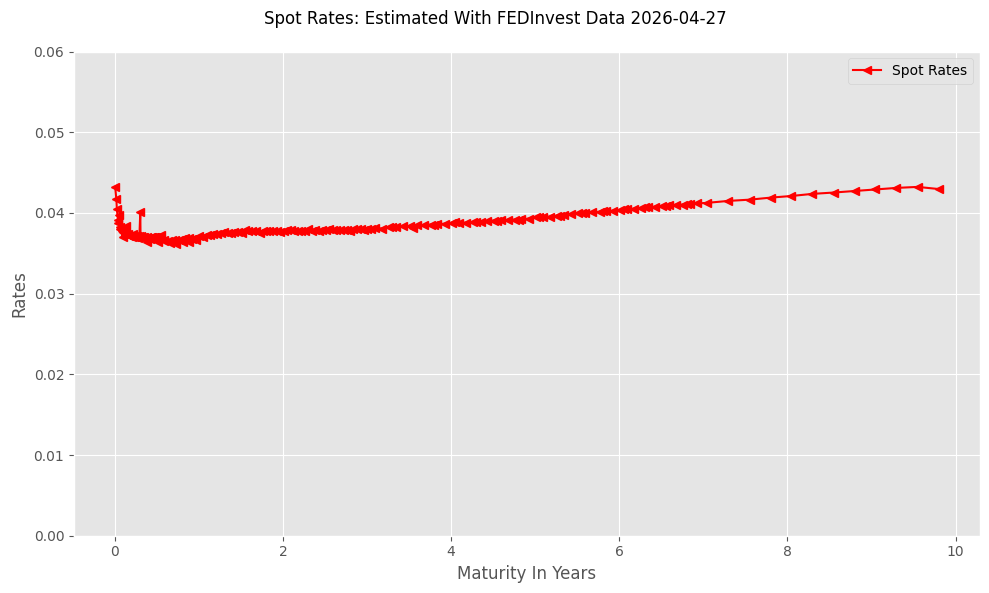

In [58]:
settlement=date(2025,4,27)

# Initialize a dictionary to hold plot-saving configurations.
save_config={}


# Initialize a dictionary to hold plot-saving configurations.
save_config={}
string_date='04/27/2026'

# Set the x-axis and y-axis data for the plot.
xaxis=maturity_years            #Maturity relative to 1/21/2025
data=[Estimated_Zeros['Spot Rates']]       #y-axis data

# Define the file name and folder for the saved plot.


# Attempt to extract the plot title from the file name.
try:
    title = save_config['File Name'][:-4]
#'File' key not found or string is too short), set a default title.
except:
    title = 'Spot Rates: Estimated With FEDInvest Data '+my_date.strftime('%Y-%m-%d')

# Define labels for the data series, y-axis, and x-axis.
series=['Spot Rates']
ylabel='Rates'
xlabel='Maturity In Years'

# Set plot aesthetics: marker styles, y-axis limits, figure size, and color.
markers=['<']
ylim=[0.0,0.06]
size=(10,6)
# Define colors as red
colors=['r']

# Call the plotting function with all the prepared data and configurations
one_y_axis(xaxis, data, title, series, xlabel, ylabel, markers, size, ylim,
           save_config=save_config,colors=colors)

:::{dropdown} ✨ AI Study Assistant
:open:

Select a prompt below to open Google AI and explore these concepts further. *(Sign in to save your chat history!)*

---

✨ [**Why use least squares to estimate zero prices? ↗**](https://www.google.com/search?udm=50&q=Why+use+least+squares+to+estimate+zero+prices?)

---

✨ [**Is it necessary to interpolate between least square estimates of zero prices? ↗**](https://www.google.com/search?udm=50&q=Is+it+necessary+to+interpolate+between+least+square+estimates+of+zero+prices?)

---

✨ [**Does it make sense to estimate zero prices with corporate bonds? ↗**](https://www.google.com/search?udm=50&q=Does+it+make+sense+to+estimate+zero+prices+with+corporate+bonds?)


:::